# Exercise 2: Fundamental Matrix and Epipolar Geometry

This lab explores the fundamental matrix and epipolar geometry — essential concepts for stereo vision and 3D reconstruction from multiple views.

### Learning Objectives
- Understand the relationship between projection matrices and the fundamental matrix
- Implement the fundamental matrix computation
- Visualize and interpret epipolar geometry

In [1]:
# Import the necessary Libraries 
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Set up paths
image_file_1 = "R0020849.jpg"
image_file_2 = "R0020850.jpg"


### Setup: Camera Parameters and Data Loading

Within the following part the parameters of the internal and external orientation are provided and read to the storage. The code block needs to be executed every time the kernel is restarted. 

**Hint:** It is highly recommended to check the source files mentioned in the comments below to match the parameters in the code with the parameters from the file. There is a high chance to receive questions related to that within the exam.


In [2]:
K = np.array([[-3933.36363636, -0.00000000, 2143.50000000], [-0.00000000, 3933.36363636, 1423.50000000], [0.00000000, 0.00000000, 1.00000000]])

R1 = np.array([[-0.867233884963, -0.496431897214, -0.038219892721],
                [0.497756374147, -0.862573995849, -0.090579764190],
                [0.011999198600, -0.097578036019, 0.995155538657]])
X1 = np.array([513010.498970, 5427654.064230, 514.392000])

R2 = np.array([[-0.839539757811, -0.528716554759, -0.125027196158],
                [0.538291662815, -0.840647830782, -0.059609649767],
                [-0.073587232584, -0.117345768246, 0.990360989678]])
X2 = np.array([512996.502990, 5427678.079250, 513.677870])

Compute the 3×4 projection matrices for both cameras.

In [4]:
def compute_projection_matrix(K, R, t):
    Rt = np.hstack([R, -R @ t.reshape(-1, 1)])
    P = K @ Rt    
    return P

# Compute projection matrices
P1 = compute_projection_matrix(K, R1, X1)
P2 = compute_projection_matrix(K, R2, X2)

### Task 1: Compute Fundamental Matrix (5 points)

Calculate the fundamental matrix F using the projection matrices. The fundamental matrix encodes the epipolar geometry between the two cameras.

#### Expected Output
- `F`: 3×3 fundamental matrix 


In [5]:
def compute_fundamental_matrix(P1, P2, X1):
    """
    Compute fundamental matrix F from projection matrices.
    Parameters:
        P1: 3x4 projection matrix of image 1
        P2: 3x4 projection matrix of image 2
        X1: 4x1 camera center of image 1 in homogeneous coordinates
    Returns:
        F: 3x3 fundamental matrix
    """
    F = None
    
    # YOUR CODE HERE
    # Ensure shapes
    X1 = np.asarray(X1).reshape(-1)              # (4,)
    e2 = (P2 @ X1).reshape(-1)                   # epipole in image 2 (3,)

    # Skew-symmetric matrix of e2: [e2]_x
    ex, ey, ez = e2
    e2x = np.array([[0,   -ez,  ey],
                    [ez,   0,  -ex],
                    [-ey, ex,   0]], dtype=float)

    # Fundamental matrix: F = [e2]_x * P2 * pinv(P1)
    F = e2x @ P2 @ np.linalg.pinv(P1)

    # Enforce rank-2 constraint
    U, S, Vt = np.linalg.svd(F)
    S[-1] = 0.0
    F = U @ np.diag(S) @ Vt

    # Optional normalization (helps readability)
    nrm = np.linalg.norm(F)
    if nrm > 0:
        F = F / nrm
    
    return F

# Camera center X0 in homogeneous coordinates
X1_homo = np.append(X1, 1)

# Compute fundamental matrix
F = compute_fundamental_matrix(P1, P2, X1_homo)

# Display Fundamental Matrix
print("Fundamental Matrix \nF =")
for row in F:
    print(f"    [{row[0]:20.12f}  {row[1]:20.12f}  {row[2]:20.12f}]")
print("\nMatrix Properties:")
print(f"  Determinant: {np.linalg.det(F):.2e}")
print(f"  Rank: {np.linalg.matrix_rank(F)}")

Fundamental Matrix 
F =
    [     -0.000000042332       -0.000000055084        0.002038852632]
    [      0.000000041684       -0.000000002507       -0.000013626855]
    [     -0.001844489885        0.000156566409       -0.999996208112]

Matrix Properties:
  Determinant: 1.65e-30
  Rank: 2


In [ ]:
## Do not change cell - required for auto-grading ## 

**Question 1:** What is the rank of the fundamental matrix, and why does it have this property? What does the determinant being approximately zero indicate geometrically?


The fundamental matrix has rank 2. This property arises because the epipolar geometry between two pinhole cameras constrains corresponding image points to lie on epipolar lines, and the fundamental matrix maps points in one image to lines in the other image. As a result, the fundamental matrix has a one-dimensional null space, corresponding to the epipole, which enforces the rank-2 constraint.

The determinant of the fundamental matrix being approximately zero indicates that the matrix is singular, which is a direct consequence of its rank being 2 instead of 3. Geometrically, this means that there exists a non-zero vector (the epipole) that is mapped to zero, i.e., all epipolar lines intersect at the epipole. This reflects the fact that the epipole is the projection of one camera center into the other image and confirms a valid epipolar geometry between the two views.

### Task 2: Compute Epipolar Line (3 points)

Implement the function to compute the epipolar line in image 2 corresponding to a point in image 1.

In [8]:
def compute_epipolar_line(F, point):
    """
    Compute epipolar line for a point in image 1
    Parameters:
        F: 3x3 fundamental matrix
        point: (x, y) pixel coordinates in image 1
    Returns:
        l_prime: (a, b, c) line parameters where ax + by + c = 0
    """
    l_prime = None
    
    # YOUR CODE HERE
    x, y = point

    # homogeneous point in image 1
    p = np.array([x, y, 1.0], dtype=float)

    # epipolar line in image 2: l' = F * p
    l_prime = F @ p  # [a, b, c]

    # optional normalization (for numerical stability)
    ab_norm = np.linalg.norm(l_prime[:2])
    if ab_norm > 0:
        l_prime = l_prime / ab_norm
    
    return l_prime

# Test with a sample point
test_point = (2000, 1500)
test_line = compute_epipolar_line(F, test_point)
print(f"Test point: {test_point}")
print(f"Epipolar line l' = (a={test_line[0]:.6f}, b={test_line[1]:.6f}, c={test_line[2]:.6f})")

Test point: (2000, 1500)
Epipolar line l' = (a=0.999379, b=0.035232, c=-2378.420288)


In [ ]:
## Do not change cell - required for auto-grading ## 

### Task 3: Visualize Epipolar Lines for Test Points (5 points)
Use the `compute_epipolar_line()` function from Task 2 to compute and visualize epipolar lines for test points to verify your implementation and understand the geometric relationship.

#### Expected Output

- **Left plot**: Image 1 with marked test points (colored marks with labels)
- **Right plot**: Image 2 with corresponding epipolar lines (same colors as points)
- **Table**: Line parameters $(a, b, c)$ for each epipolar line

The visualization demonstrates that points at different locations in image 1 produce different epipolar lines in image 2.


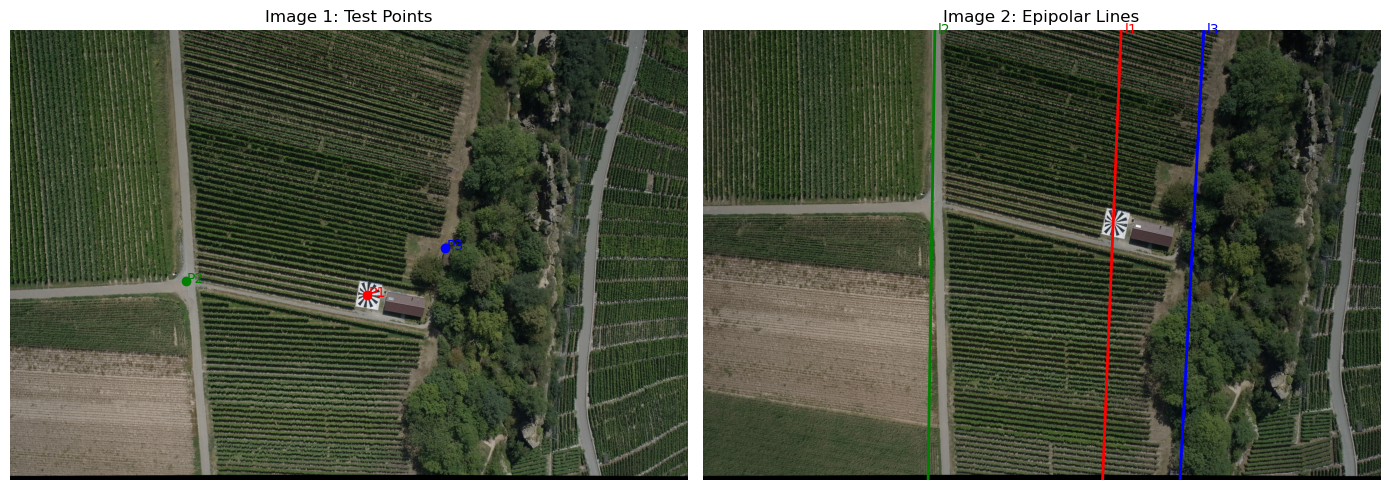

Epipolar Line Parameters

Point  |   x [pix]    |   y [pix]    |           a            |           b            |           c           
 ----------------------------------------------------------------------------------------------------
  1    |    2258.5    |    1678.5    |        0.999151        |        0.041195        |      -2646.884234     
  2    |    1110.5    |    1586.5    |        0.999887        |        0.015060        |      -1470.025180     
  3    |    2750.5    |    1378.5    |        0.998607        |        0.052766        |      -3167.792176     


In [9]:
# Load both images
image1 = cv2.imread(image_file_1)
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.imread(image_file_2)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

# Define test points in image 1
test_points = [(2258.5, 1678.5),  # Point 1
    (1110.5, 1586.5),  # Point 2
    (2750.5, 1378.5)]  # Point 3

# YOUR CODE HERE
# Colors for points/lines
colors = ["red", "green", "blue"]

epipolar_lines = []

H, W, _ = image2_rgb.shape

# Prepare figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image1_rgb)
axes[0].set_title("Image 1: Test Points")
axes[0].axis("off")

axes[1].imshow(image2_rgb)
axes[1].set_title("Image 2: Epipolar Lines")
axes[1].axis("off")

for i, (pt, color) in enumerate(zip(test_points, colors)):
    x, y = pt

    # plot test point in image 1
    axes[0].plot(x, y, marker="o", color=color)
    axes[0].text(x + 10, y + 10, f"P{i+1}", color=color)

    # compute epipolar line in image 2
    l = compute_epipolar_line(F, pt)
    epipolar_lines.append(l)

    a, b, c = l

    # find two points on the line for plotting
    if abs(b) > abs(a):
        x0, x1 = 0, W - 1
        y0 = -c / b
        y1 = -(a * (W - 1) + c) / b
    else:
        y0, y1 = 0, H - 1
        x0 = -c / a
        x1 = -(b * (H - 1) + c) / a

    # draw line on image 2
    axes[1].plot([x0, x1], [y0, y1], color=color, linewidth=2)
    axes[1].text(x0 + 20, y0 + 20, f"l{i+1}", color=color)

plt.tight_layout()
plt.show()


# Display results table
print("Epipolar Line Parameters\n")
print(f"{'Point':^6} | {'x [pix]':^12} | {'y [pix]':^12} | {'a':^22} | {'b':^22} | {'c':^22}\n", "-" * 100)
for i, (pt, line) in enumerate(zip(test_points, epipolar_lines)):
    print(f"{i+1:^6} | {pt[0]:^12.1f} | {pt[1]:^12.1f} | {line[0]:^22.6f} | {line[1]:^22.6f} | {line[2]:^22.6f}")

In [ ]:
## Do not change cell - required for auto-grading ## 

**Question 2:** Observe the direction of the epipolar lines in image 2. Why do they run approximately in a specific direction? How does this relate to the camera motion between the two images?


The epipolar lines in image 2 run approximately in the same (nearly vertical) direction because the relative motion between the two cameras is dominated by a translation along a fixed direction (approximately horizontal baseline) with only a small rotational component. In this configuration, the epipole lies far outside the image (or close to infinity), which causes the epipolar lines to appear almost parallel. Geometrically, the direction of the epipolar lines is perpendicular to the dominant camera translation direction, directly reflecting the relative camera motion between the two images.

**Question 3:** How can epipolar geometry be used to improve stereo matching efficiency? What is the advantage of knowing the fundamental matrix?


Epipolar geometry improves stereo matching efficiency by restricting where corresponding points can appear in the second image. Instead of searching for a match across the entire image, each point in the first image only needs to be searched along a specific line in the second image. This greatly reduces the search area, making the matching process faster and more reliable.

Knowing the fundamental matrix provides this geometric relationship between the two images. It allows incorrect matches to be rejected based on geometric consistency, improves robustness against noise and ambiguities, and leads to more accurate stereo matching and better 3D reconstruction results.